# Co2 Modelling

In [381]:
import pandas as pd

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = f"images/{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def load_pandas_df_from_csv():
    return pd.read_csv("LAEI-2019-Emissions-Summary-including-Forecast/2019filteredatacsv.csv")

emissions_2019 = load_pandas_df_from_csv()

In [382]:
emissions_2019.drop(columns=[
    'Year', 'Emissions Unit', 'LAEI 1km2 ID', 'Grid ID 2019',
    'bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'hc', 'hcl',
    'hg', 'n2o', 'nh3', 'nmvoc', 'pb', 'pcb', 'so2', 
    'nox', 'pm10', 'pm2.5'
], inplace=True)

In [383]:
emissions_2019.info()
emissions_2019['co2'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143976 entries, 0 to 143975
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Easting               143976 non-null  int64  
 1   Northing              143976 non-null  int64  
 2   Borough               143976 non-null  object 
 3   Zone                  143976 non-null  object 
 4   Main Source Category  143976 non-null  object 
 5   Sector                143976 non-null  object 
 6   Source                143976 non-null  object 
 7   co2                   112836 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 8.8+ MB


count    112836.000000
mean        257.580418
std        3642.241790
min           0.000000
25%           0.000000
50%           0.901680
75%          56.987074
max      747457.600000
Name: co2, dtype: float64

## Feature Engineering from Spatial Data

In [384]:
# quickly encode Source for plotting
emissions_2019['Source Encoded'], source_categories = pd.factorize(emissions_2019['Source'])

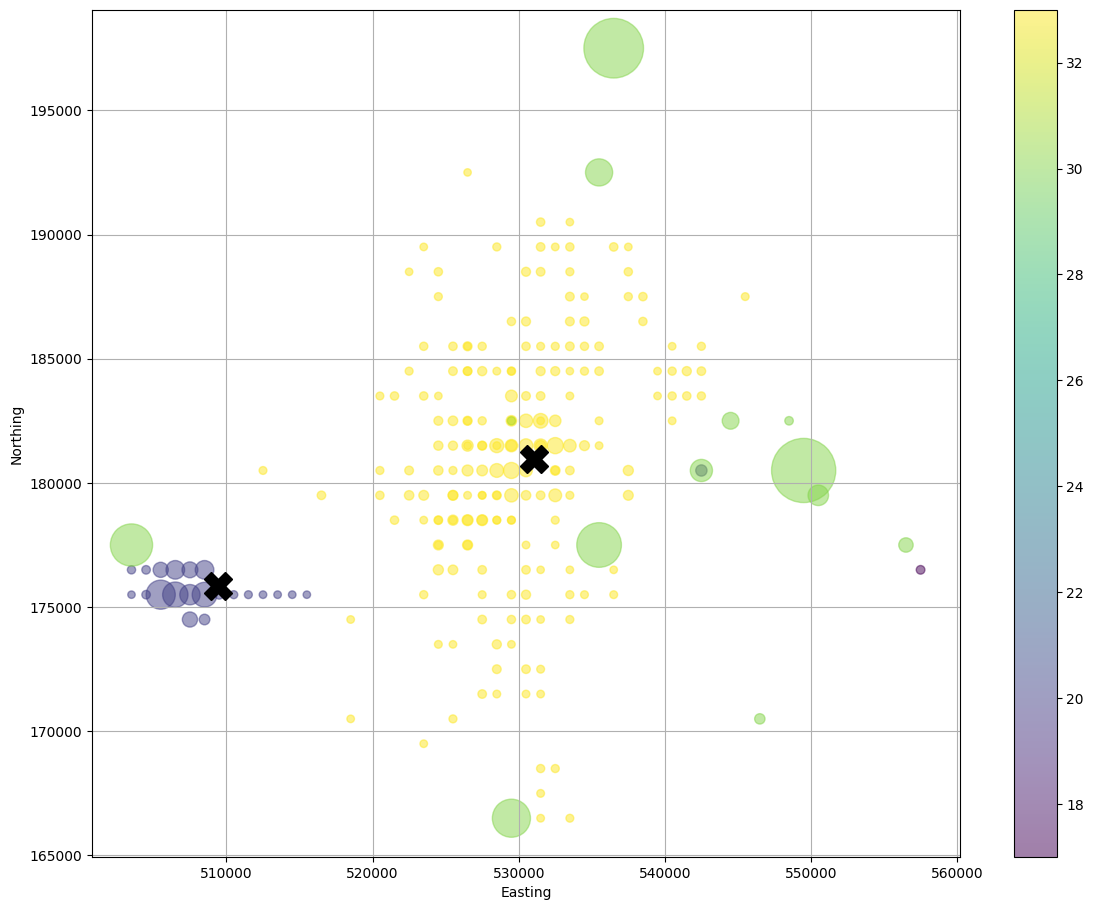

In [385]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

quantile = .998
high_emitters = emissions_2019[emissions_2019['co2'] > emissions_2019['co2'].quantile(quantile)]
kmeans = KMeans(2, n_init=5, random_state=42)
kmeans.fit_transform(high_emitters[['Northing', 'Easting']])

# plot high emitters and central cluster center
high_emitters.plot(kind='scatter', x='Easting', y='Northing', grid=True, 
            s=high_emitters['co2'] / 350, # size based on volume of emissions
            c=high_emitters['Source Encoded'], # colour based on emission source
            cmap='viridis',
            alpha=0.5,
            figsize=(14,11))

plt.plot(kmeans.cluster_centers_[:, 1],
         kmeans.cluster_centers_[:, 0],
         linestyle='', color='black', marker='X', markersize=20,
         label='Cluster centers')

plt.show()

In [386]:
emissions_2019.drop(columns=['Source Encoded'], inplace=True)
print(f'Cluster Center (Roughly Central London): {kmeans.cluster_centers_}')

Cluster Center (Roughly Central London): [[180980.         531025.        ]
 [175846.15384615 509423.07692308]]


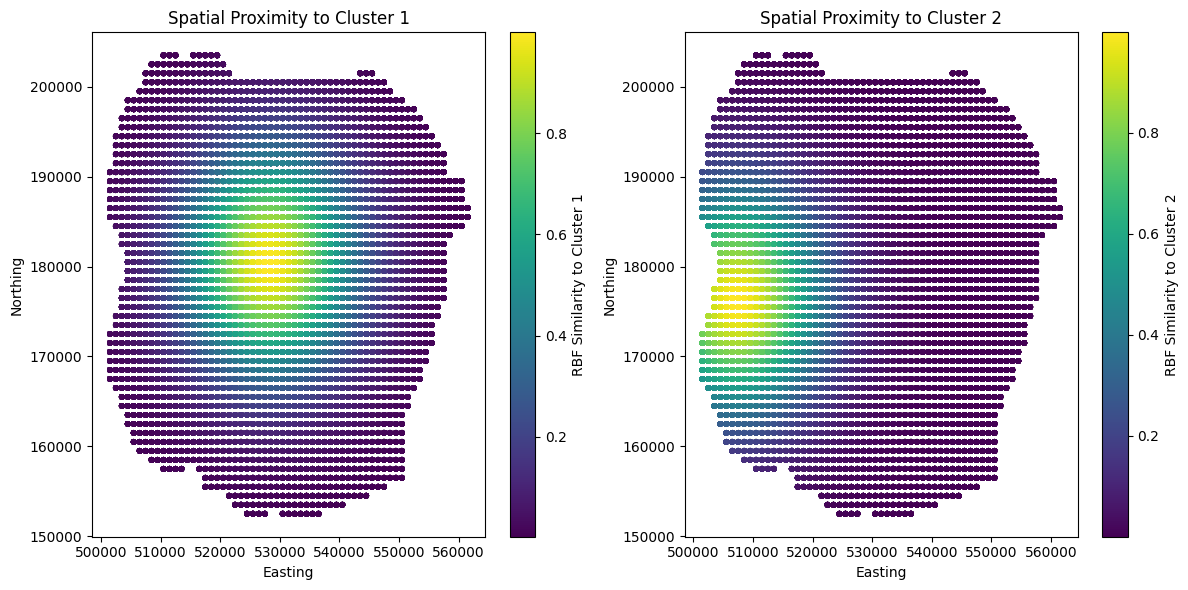

In [387]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class ClusterProximity(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.predefined_cluster_centers = np.array([[528234.513, 180393.805], 
                                                    [507366.666, 176100.000]])
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.scaler.fit(X.values)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X.values)
        cluster_centers_scaled = self.scaler.transform(self.predefined_cluster_centers)
        return rbf_kernel(X_scaled, cluster_centers_scaled, gamma=1.0)
        
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i+1} proximity" for i in range(self.predefined_cluster_centers.shape[0])]

cluster_proximity = ClusterProximity()
cluster_similarities = cluster_proximity.fit_transform(emissions_2019[['Easting', 'Northing']])

num_clusters = len(cluster_similarities[0])

plt.figure(figsize=(12, 6))
for i in range(num_clusters):
    plt.subplot(1, num_clusters, i+1)
    plt.scatter(emissions_2019['Easting'], emissions_2019['Northing'], 
                c=cluster_similarities[:, i], cmap='viridis', s=10)
    plt.colorbar(label=f'RBF Similarity to Cluster {i+1}')
    plt.xlabel('Easting')
    plt.ylabel('Northing')
    plt.title(f'Spatial Proximity to Cluster {i+1}')
plt.tight_layout()

save_fig('cluster-spatial-proximity')
plt.show()


## Split Train-Test Sets, Extract Labels

In [388]:
from sklearn.model_selection import train_test_split

emissions_2019 = emissions_2019.dropna(subset=['co2'])
strat_train_set, strat_test_set = train_test_split(emissions_2019, test_size=0.2, stratify=emissions_2019['Source'])
X = strat_train_set.drop('co2', axis=1)
y = strat_train_set['co2'].copy()

In [389]:
X.head(5)

,Easting,Northing,Borough,Zone,Main Source Category,Sector,Source
63685,549500,186500,Havering,Outer,Transport,Rail,Passengers
48729,553500,187500,Havering,Outer,Transport,Road Transport,Car - Diesel
17771,521500,165500,Non GLA,Non GLA,Transport,Road Transport,Non-TfL Bus / Coach
50233,510500,165500,Non GLA,Non GLA,Transport,Road Transport,Car - Diesel
116660,533500,185500,Hackney,Inner,Industrial and Commercial,Gas Leakage,Natural Gas Leakage


In [390]:
y.describe()

count     90268.000000
mean        254.961496
std        3745.498701
min           0.000000
25%           0.000000
50%           0.923791
75%          56.600900
max      747457.600000
Name: co2, dtype: float64

## Transformation Pipeline

- Add features: proximity to central London (rbf)
- 1-hot encode categorical features
- Normalise other numerical features

> 'Source' could instead be ordinally encoded, based on largest contributor of emissions.

In [391]:
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

target_encoding_pipeline = make_pipeline(
    TargetEncoder(),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('cluster_simil_pipeline', ClusterProximity(), ['Easting', 'Northing']),
    ('target_encoder_pipeline', target_encoding_pipeline, ['Borough', 'Main Source Category', 'Sector', 'Source']),
    ('num', StandardScaler(), ['Easting', 'Northing']),
    ('cat', OneHotEncoder(), ['Zone']),
])
X_prepared = preprocessing.fit_transform(X, y) # labels required for target encoding
y = np.log1p(y) # to address extreme skew
X_prepared.shape

(90268, 12)

In [392]:
feature_names = preprocessing.get_feature_names_out()
X_prepared_df = pd.DataFrame(X_prepared, columns=feature_names)
X_prepared_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90268 entries, 0 to 90267
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   cluster_simil_pipeline__Cluster 1 proximity    90268 non-null  float64
 1   cluster_simil_pipeline__Cluster 2 proximity    90268 non-null  float64
 2   target_encoder_pipeline__Borough               90268 non-null  float64
 3   target_encoder_pipeline__Main Source Category  90268 non-null  float64
 4   target_encoder_pipeline__Sector                90268 non-null  float64
 5   target_encoder_pipeline__Source                90268 non-null  float64
 6   num__Easting                                   90268 non-null  float64
 7   num__Northing                                  90268 non-null  float64
 8   cat__Zone_Central                              90268 non-null  float64
 9   cat__Zone_Inner                                902

## Fit Models, Compute Cross Validation Scores & Tune

In [393]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score

folds = 5

linear_regression = make_pipeline(preprocessing, Ridge())
linear_regression.fit(X, y)

linear_regression_maes = -cross_val_score(
    linear_regression, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

linear_regression_rmses = -cross_val_score(
    linear_regression, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

linear_regression_r2_scores = cross_val_score(
    linear_regression, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Linear Regression Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(linear_regression_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(linear_regression_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(linear_regression_r2_scores).describe()))

Linear Regression Cross Validation (5 folds) Performance Metrics

MAEs:
count    5.000000
mean     1.004346
std      0.004708
min      0.998520
25%      1.000119
50%      1.006248
75%      1.008315
max      1.008527
dtype: float64

RMSEs:
count    5.000000
mean     1.466967
std      0.006195
min      1.461584
25%      1.461848
50%      1.465620
75%      1.469266
max      1.476518
dtype: float64

R2s:
count    5.000000
mean     0.659949
std      0.003766
min      0.656357
25%      0.657273
50%      0.658384
75%      0.662541
max      0.665192
dtype: float64


In [394]:
from sklearn.ensemble import RandomForestRegressor

folds = 3

random_forest_regressor = make_pipeline(preprocessing, RandomForestRegressor(n_jobs=-1))
random_forest_regressor.fit(X, y)

random_forest_maes = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

random_forest_rmses = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

random_forest_r2_scores = cross_val_score(
    random_forest_regressor, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Random Forest Regressor Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(random_forest_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(random_forest_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(random_forest_r2_scores).describe()))

Random Forest Regressor Cross Validation (3 folds) Performance Metrics

MAEs:
count    3.000000
mean     0.684565
std      0.008113
min      0.676537
25%      0.680468
50%      0.684399
75%      0.688579
max      0.692759
dtype: float64

RMSEs:
count    3.000000
mean     1.163616
std      0.006798
min      1.158581
25%      1.159749
50%      1.160918
75%      1.166133
max      1.171349
dtype: float64

R2s:
count    3.000000
mean     0.786404
std      0.001740
min      0.784998
25%      0.785431
50%      0.785864
75%      0.787106
max      0.788349
dtype: float64


In [343]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

folds = 2

random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = {
    'random_forest__n_estimators': [100, 200],
    'random_forest__max_depth': [None, 20],
    'random_forest__min_samples_split': [2, 5],
    'random_forest__min_samples_leaf': [1],
    'random_forest__max_features': [4, 6, 8]
}
grid_search = GridSearchCV(random_forest_pipeline, param_grid, cv=folds,
                           scoring='neg_root_mean_squared_error', n_jobs=-1, 
                           verbose=1, error_score='raise')

grid_search.fit(X, y)

Fitting 2 folds for each of 24 candidates, totalling 48 fits


GridSearchCV(cv=2, error_score='raise',
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('cluster_simil_pipeline',
                                                                         ClusterProximity(),
                                                                         ['Easting',
                                                                          'Northing']),
                                                                        ('target_encoder_pipeline',
                                                                         Pipeline(steps=[('targetencoder',
                                                                                          TargetEncoder()),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['Borough',
                                                                          'Main '
                                                                          'Source '
                                                                          'Category',
                                                                          'Sector',
                                                                          'Source'...
                                                                         OneHotEncoder(),
                                                                         ['Zone'])])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'random_forest__max_depth': [None, 20],
                         'random_forest__max_features': [4, 6, 8],
                         'random_forest__min_samples_leaf': [1],
                         'random_forest__min_samples_split': [2, 5],
                         'random_forest__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [345]:
grid_search.best_params_

{'random_forest__max_depth': None,
 'random_forest__max_features': 4,
 'random_forest__min_samples_leaf': 1,
 'random_forest__min_samples_split': 2,
 'random_forest__n_estimators': 200}

In [365]:
from sklearn.ensemble import RandomForestRegressor

folds = 3

best_performing_model = RandomForestRegressor(
    max_features=4,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    n_jobs=-1,
)

random_forest_regressor = make_pipeline(preprocessing, best_performing_model)
random_forest_regressor.fit(X, y)

random_forest_maes = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

random_forest_rmses = -cross_val_score(
    random_forest_regressor, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

random_forest_r2_scores = cross_val_score(
    random_forest_regressor, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'Random Forest Regressor Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(random_forest_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(random_forest_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(random_forest_r2_scores).describe()))

Random Forest Regressor Cross Validation (3 folds) Performance Metrics

MAEs:
count    3.000000
mean     0.674933
std      0.002683
min      0.672024
25%      0.673745
50%      0.675465
75%      0.676388
max      0.677311
dtype: float64

RMSEs:
count    3.000000
mean     1.125032
std      0.008915
min      1.118445
25%      1.119960
50%      1.121474
75%      1.128326
max      1.135177
dtype: float64

R2s:
count    3.000000
mean     0.800146
std      0.003880
min      0.797737
25%      0.797908
50%      0.798079
75%      0.801351
max      0.804622
dtype: float64


In [366]:
importances = random_forest_regressor.named_steps["randomforestregressor"].feature_importances_
feature_names = random_forest_regressor.named_steps["columntransformer"].get_feature_names_out()
sorted(zip(importances, feature_names), reverse=True)

[(np.float64(0.5258888074222693), 'target_encoder_pipeline__Source'),
 (np.float64(0.16313935935818505), 'target_encoder_pipeline__Sector'),
 (np.float64(0.06912294457992782),
  'cluster_simil_pipeline__Cluster 1 proximity'),
 (np.float64(0.061811903253321566),
  'cluster_simil_pipeline__Cluster 2 proximity'),
 (np.float64(0.050285827790435646), 'num__Northing'),
 (np.float64(0.043334716224083865), 'num__Easting'),
 (np.float64(0.03765138244397395), 'target_encoder_pipeline__Borough'),
 (np.float64(0.03724524235981436),
  'target_encoder_pipeline__Main Source Category'),
 (np.float64(0.004002382252720678), 'cat__Zone_Outer'),
 (np.float64(0.0036088785406835485), 'cat__Zone_Non GLA'),
 (np.float64(0.0029289595651628814), 'cat__Zone_Inner'),
 (np.float64(0.0009795962094212459), 'cat__Zone_Central')]

In [379]:
from xgboost import XGBRegressor

folds = 10

xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=6,
    n_estimators=1000,
    subsample=0.9
)

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("xgb", xgb_model),
])
xgb_pipeline.fit(X, y)

xgb_maes = -cross_val_score(
    xgb_pipeline, X, y, scoring='neg_mean_absolute_error', cv=folds, error_score='raise')

xgb_rmses = -cross_val_score(
    xgb_pipeline, X, y, scoring='neg_root_mean_squared_error', cv=folds, error_score='raise')

xgb_r2_scores = cross_val_score(
    xgb_pipeline, X, y, scoring='r2', cv=folds, error_score='raise')

print(f'XGBoost Cross Validation ({folds} folds) Performance Metrics')
print('\nMAEs:\n' + str(pd.Series(xgb_maes).describe()))
print('\nRMSEs:\n' + str(pd.Series(xgb_rmses).describe()))
print('\nR2s:\n' + str(pd.Series(xgb_r2_scores).describe()))

XGBoost Cross Validation (10 folds) Performance Metrics

MAEs:
count    10.000000
mean      0.613764
std       0.018502
min       0.589928
25%       0.600092
50%       0.608119
75%       0.626459
max       0.641624
dtype: float64

RMSEs:
count    10.000000
mean      0.948432
std       0.027206
min       0.898553
25%       0.928202
50%       0.960091
75%       0.965396
max       0.984530
dtype: float64

R2s:
count    10.000000
mean      0.856741
std       0.009513
min       0.834627
25%       0.854341
50%       0.858529
75%       0.861423
max       0.869970
dtype: float64


In [380]:
importances = xgb_pipeline.named_steps["xgb"].feature_importances_
feature_names = xgb_pipeline.named_steps["preprocessing"].get_feature_names_out()
sorted(zip(importances, feature_names), reverse=True)

[(np.float32(0.36442754), 'target_encoder_pipeline__Source'),
 (np.float32(0.26055267), 'cat__Zone_Non GLA'),
 (np.float32(0.053089127), 'cat__Zone_Outer'),
 (np.float32(0.04598227), 'target_encoder_pipeline__Main Source Category'),
 (np.float32(0.04470157), 'cat__Zone_Inner'),
 (np.float32(0.038574822), 'cluster_simil_pipeline__Cluster 1 proximity'),
 (np.float32(0.036643703), 'num__Northing'),
 (np.float32(0.03531835), 'num__Easting'),
 (np.float32(0.034404855), 'cat__Zone_Central'),
 (np.float32(0.031828817), 'target_encoder_pipeline__Borough'),
 (np.float32(0.028251072), 'cluster_simil_pipeline__Cluster 2 proximity'),
 (np.float32(0.026225215), 'target_encoder_pipeline__Sector')]